# End-to-End Evaluation — results & trend

Reads the JSON reports written by `scripts/evaluate_all.py` and renders them as
tables and trend charts, so results can be compared **across evaluation sessions
over time** instead of scrolling terminal output.

The reports in `data/evaluations/` **are** the history — this notebook only reads
them. Re-running §1 is optional and only needed to add a new point; everything
below works offline from what is already on disk.

The unit of comparison is the **session**: one `evaluate_all.py` invocation runs
the pipeline over the real data *and* over the synthetic set and scores both, so
one session is one measurement of one state of the system even though it spans
two pipeline runs.

**Two things to keep in mind while reading (see `docs/End-to-End-Evaluation-Guide.md`):**

- **Leakage.** The Stage-4.25 gate and the Stage-4.5 matcher were both trained on
  the gold labels. Read `gate_pass` / `ml_auto_merge` only from a `strict`
  holdout report. The **clustering headline is leakage-free at any holdout**
  while `fs_feeds_clustering` and `ml_feeds_clustering` are both off, because
  clustering then uses only deterministic-rule edges.
- **Each stage is scored on the pool it actually saw.** The gate never sees pairs
  the rules already auto-merged; the matcher only sees gate survivors. The
  `scored_pairs` column says how many labeled pairs reached each stage.

## 0. Setup

In [2]:
import subprocess
import sys
from pathlib import Path


def _service_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "data").is_dir() and (d / "src").is_dir():
            return d
    raise FileNotFoundError("could not locate empi-service/ (no ancestor has data/ + src/)")


SERVICE_ROOT = _service_root(Path.cwd())
if str(SERVICE_ROOT) not in sys.path:
    sys.path.insert(0, str(SERVICE_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.config import settings
from src.evaluation.report_io import (
    cluster_frame,
    funnel_frame,
    load_reports,
    loss_frame,
    metric_history,
    stage_frame,
    summary_frame,
    transitivity_frame,
    triage_history,
    triage_matrix,
    triage_report,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

print("service root:", SERVICE_ROOT)
print("runs dir    :", settings.runs_dir)

service root: c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service
runs dir    : C:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\runs


### Chart styling

Three categorical hues from the validated palette, assigned to series in a fixed
sorted order so a series keeps its colour when other series appear or disappear.
Every chart is followed by its table view.

In [3]:
SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]  # blue, orange, aqua
INK, MUTED, GRID_C = "#0b0b0b", "#52514e", "#e6e5e1"


def color_map(series_names) -> dict:
    """Stable series -> colour. Keyed on the series name, never on its rank in
    the current chart, so filtering one series out never repaints the others."""
    return {name: SERIES_COLORS[i % len(SERIES_COLORS)]
            for i, name in enumerate(sorted(series_names))}


plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 9,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.edgecolor": GRID_C,
    "axes.labelcolor": MUTED,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID_C,
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
})

## 1. (Optional) Run evaluations to add a new point

Skip this if you only want to read existing results.

`scripts/evaluate_all.py` does the whole thing in one session: pipeline over the
real data → score vs gold at **both** holdouts → pipeline over synthetic → score
vs entity truth. Gold gets both holdouts on purpose — `none` gives the tighter
clustering headline (8x more labeled positives), `strict` gives the honest
gate/matcher numbers.

Set `REUSE_REAL_RUN` to an existing `run_id` to skip re-running the real-data
pipeline, which is the slow part.

In [4]:
RUN_EVALUATIONS = True    # flip to True to add a new session
SESSION_ID = None          # e.g. "gate_v2_baseline"; None -> UTC timestamp
REUSE_REAL_RUN = None      # an existing run_id, to skip the slow real-data run

if RUN_EVALUATIONS:
    cmd = [sys.executable, "scripts/evaluate_all.py"]
    if SESSION_ID:
        cmd += ["--session-id", SESSION_ID]
    if REUSE_REAL_RUN:
        cmd += ["--reuse-real-run", REUSE_REAL_RUN]
    print("$", " ".join(str(c) for c in cmd), "\n")
    # Streamed rather than captured: the real-data pipeline run takes minutes
    # and a silent cell that long is indistinguishable from a hung one.
    proc = subprocess.run(cmd, cwd=SERVICE_ROOT)
    if proc.returncode:
        raise RuntimeError("evaluate_all.py failed — see the output above.")
else:
    print("Skipped — reading stored reports only.")

$ c:\Users\MiguelGarcia\.conda\envs\capstone_env\python.exe scripts/evaluate_all.py 



## 2. What results exist

In [5]:
reports = load_reports()
print(f"{len(reports)} stored report(s)\n")

summary = summary_frame(reports)
summary

3 stored report(s)



,session_id,evaluated_utc,run_id,source,holdout,labeled_pairs,positives,precision,recall,f1,TP,FP,FN,git_sha
0,20260729T145825Z,2026-07-29T15:02:20+00:00,20260729T145825Z_synthetic,synthetic,n/a,10000,2000,0.9978,0.6820,0.8102,1364,3,636,bedca12a
1,20260729T145825Z,2026-07-29T15:02:08+00:00,20260729T145825Z_real,gold,strict,30936,2495,0.9887,0.3848,0.5540,960,11,1535,bedca12a
2,20260729T145825Z,2026-07-29T15:02:04+00:00,20260729T145825Z_real,gold,none,204805,62537,0.9977,0.3817,0.5521,23869,54,38668,bedca12a


## 3. One report in detail

`FOCUS = 0` is the most recently evaluated report. Change it to inspect another
row of the table above.

In [17]:
FOCUS = 1

report = reports[FOCUS]
holdout = report["leakage"]["restriction"]
print(f"run {report['run_id']}  |  {report['label_source']}  |  holdout: {holdout}")
print(f"evaluated {report['evaluated_utc']}  |  pipeline git sha: {report['git_sha']}")
print(f"{report['universe']['labeled_pairs']} labeled pairs, "
      f"{report['universe']['positives']} positive")
if report["leakage"].get("note"):
    print("\n!", report["leakage"]["note"])

run 20260729T145825Z_real  |  gold  |  holdout: strict
evaluated 2026-07-29T15:02:08+00:00  |  pipeline git sha: bedca12ac1e190d03f14083757b556330fee082c
30936 labeled pairs, 2495 positive


### 3.1 Triage — the three-class decision (the fair recall view)

The headline above is binary: *did we merge this pair?* That scores an
**ambiguous** pair routed to a reviewer as a miss — but routing it there is
exactly what the pipeline is supposed to do with evidence no human could
resolve. This section scores the decision the pipeline actually makes.

| gold class | should be routed to |
|---|---|
| non-match (neither flag) | `no_match` |
| ambiguous (`ambiguous_pair`) | `human_review` |
| match (`final_gold_label`) | `auto_merge` |

A pair carrying *both* flags counts as **ambiguous** — the class is a statement
about the evidence, and weak evidence belongs with a human whatever the
eventual adjudication was. `ambiguous_precedence` in the report records this.

Only gold defines the ambiguous class; synthetic and silver reports fall back
to two classes and leave `human_review` unpopulated.

In [ ]:
triage_report(report)

#### Confusion matrix

Rows are where the label says the pair belonged, columns where the pipeline
sent it. **The diagonal is correct routing.** Below the diagonal the pipeline
was too cautious (a match left in review); above it, too aggressive (a
non-match merged) — the errors on those two sides cost very different things.

In [ ]:
triage_matrix(report)          # raw counts; normalize=True for row %

In [ ]:
def plot_triage_matrix(report, title=None):
    """Confusion matrix -> annotated heatmap.

    Shaded by *row share* (per-class recall) rather than raw count: non-matches
    outnumber matches several to one here, so a count-shaded grid is one dark
    corner and two invisible rows. Each cell still prints its absolute count,
    because a rate without its denominator is not actionable.

    One sequential hue, light -> dark, per the palette's magnitude rule. Cell
    text flips to white on the dark end so every label stays legible.
    """
    counts = triage_matrix(report)
    if counts.empty:
        print("This report has no triage block (written before the section existed).")
        return
    counts = counts.drop(columns="total")
    pct = triage_matrix(report, normalize=True)

    fig, ax = plt.subplots(figsize=(6.4, 3.4))
    im = ax.imshow(pct.to_numpy(dtype=float), cmap="Blues", vmin=0, vmax=100)

    ax.set_xticks(range(len(counts.columns)), counts.columns)
    ax.set_yticks(range(len(counts.index)), counts.index)
    ax.set_xlabel("system routed to")
    ax.set_ylabel("expected route")
    ax.grid(visible=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for r in range(counts.shape[0]):
        for c in range(counts.shape[1]):
            share = pct.iat[r, c]
            share = 0.0 if pd.isna(share) else float(share)
            ax.text(c, r, f"{counts.iat[r, c]:,}\n{share:.1f}%",
                    ha="center", va="center", fontsize=8.5,
                    color="#ffffff" if share > 65 else INK)
            if r == c:   # ring the diagonal: the cells that mean "routed right"
                ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False,
                                           edgecolor=SERIES_COLORS[2], linewidth=2))

    cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
    cb.set_label("share of the expected class (%)", color=MUTED, fontsize=8)
    cb.outline.set_visible(False)
    ax.set_title(title or f"Triage routing — {report['label_source']} / {holdout}",
                 color=INK, loc="left")
    plt.tight_layout()
    plt.show()


plot_triage_matrix(report)

#### Per-route recall

`auto_merge` recall is the number to watch: it is the share of confident
matches the pipeline resolved without a human. `human_review` recall says
whether genuinely undecidable pairs are reaching a reviewer rather than being
silently dropped — a low value there is the serious failure, because a pair
dropped at `no_match` is unrecoverable.

In [ ]:
def plot_triage_history(reports, metric="recall", title=None):
    """One line per route across sessions. Colour follows the route, never its
    rank, so adding a session never repaints the series."""
    df = triage_history(reports, metric)
    if df.empty:
        print("No triage metrics stored yet.")
        return
    colors = color_map(df["series"].unique())
    fig, ax = plt.subplots(figsize=(7.6, 3.6))
    for i, (name, g) in enumerate(df.groupby("series")):
        g = g.sort_values("evaluated_utc")
        ax.plot(g["session_id"], g["value"], marker="o", markersize=6,
                linewidth=2, color=colors[name], label=name)
        last = g.iloc[-1]
        ax.annotate(f"{last['value']:.3f}", (last["session_id"], last["value"]),
                    textcoords="offset points", xytext=(8, 2 + 9 * i),
                    fontsize=8.5, color=colors[name])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.set_title(title or f"Triage {metric} by route", color=INK, loc="left")
    ax.legend(loc="lower right", ncols=3)
    ax.tick_params(axis="x", labelrotation=30)
    plt.tight_layout()
    plt.show()


plot_triage_history([r for r in reports if r.get("label_source") == report["label_source"]])

### 3.2 Per-stage decisions

`scored_pairs` < `labeled_pairs` means the stage only saw part of the labeled
set — the gate and the matcher sit downstream of filters, so this is expected,
not a defect. Their precision/recall are computed on that sub-pool only.

In [18]:
stage_frame(report)

,stage,status,target,precision,recall,f1,TP,FP,FN,scored_pairs,labeled_pairs
0,blocking,,final_gold_label,0.2198,1.0000,0.3604,2495,8857,0,30936.0,30936.0
1,rules_auto_merge,,final_gold_label,0.9989,0.3695,0.5395,922,1,1573,30936.0,30936.0
2,rules_any_confirmed,,final_gold_label,0.8873,0.6882,0.7752,1717,218,778,30936.0,30936.0
3,gate_pass,,plausible,0.7671,0.9994,0.8679,1574,478,1,4680.0,30936.0
4,ml_auto_merge,,confident_match,0.5537,0.8119,0.6584,423,341,98,2052.0,30936.0
5,clustering,,final_gold_label,0.9887,0.3848,0.5540,960,11,1535,NaN,NaN
6,ml_auto_merge (vs match label),,final_gold_label,0.5602,0.2723,0.3664,428,336,1144,2052.0,30936.0
7,fs_auto_merge (audit-only),,final_gold_label,0.7355,0.9402,0.8253,1479,532,94,4680.0,30936.0


### 3.3 Funnel and loss attribution

`clustered` is **not** a subset of the row above it: transitivity can merge a
pair that never even blocked.

In [19]:
funnel_frame(report)

,stage,positives,negatives,total
0,blocked,2495,8857,11352
1,rules_kept,2495,3108,5603
2,gate_passed,2494,481,2975
3,ml_kept,2494,481,2975
4,clustered,960,11,971


In [20]:
losses = loss_frame(report)
losses

,stage,missed,share_pct
0,left in review (no auto_merge edge),1534,99.9
1,dropped by non-match gate,1,0.1
2,rejected by deterministic rules,0,0.0
3,not blocked,0,0.0
4,ml matcher tiered no_match,0,0.0
5,record not clustered (invalid/absent),0,0.0


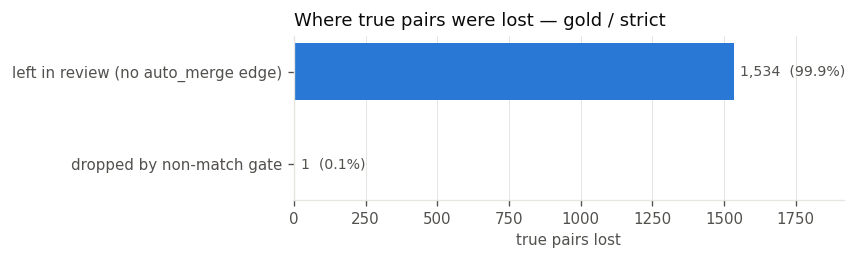

In [21]:
def plot_losses(losses: pd.DataFrame, title: str):
    """Magnitude by category -> horizontal bars, sorted. One series, so no
    legend; every bar is directly labelled instead of relying on the axis."""
    data = losses[losses["missed"] > 0]
    if data.empty:
        print("No missed true pairs to attribute.")
        return
    fig, ax = plt.subplots(figsize=(7.2, 0.42 * len(data) + 1.4))
    y = range(len(data))
    ax.barh(list(y), data["missed"], color=SERIES_COLORS[0], height=0.62)
    ax.set_yticks(list(y), data["stage"])
    ax.invert_yaxis()
    ax.set_xlabel("true pairs lost")
    ax.set_title(title, color=INK, loc="left")
    ax.grid(axis="y", visible=False)
    span = data["missed"].max()
    for i, (n, pct) in enumerate(zip(data["missed"], data["share_pct"])):
        ax.text(n + span * 0.015, i, f"{n:,}  ({pct}%)", va="center",
                fontsize=8.5, color=MUTED)
    ax.set_xlim(0, span * 1.25)
    plt.tight_layout()
    plt.show()


plot_losses(losses, f"Where true pairs were lost — {report['label_source']} / {holdout}")

### 3.4 Transitivity and cluster-level metrics

Transitive-only merges were never scored by any classifier, so their false
positives are invisible to every per-stage metric above.

In [22]:
transitivity_frame(report)

,merge_kind,n,TP,FP,precision
0,direct,969,960,9,0.9907
1,transitive_only,2,0,2,0.0000


In [23]:
# `closure_contradictions` > 0 means the truth partition asserts pairs the
# labeller marked non-matches -> read these as directional, prefer the headline.
cluster_frame([report]).T

,0
session_id,20260729T145825Z
run_id,20260729T145825Z_real
source,gold
holdout,strict
bcubed_precision,0.9369
bcubed_recall,0.901
bcubed_f1,0.9186
exact_rate,0.7514
nonsingleton_exact_rate,0.3571
nonsingleton_split,1414


## 4. Comparison over time

One point per **session**, ordered by when it was evaluated. Series are
`source / holdout` combinations, so gold and synthetic sit on the same axes
without ever being averaged together — and both halves of a session share an
x-position even though they are different pipeline runs.

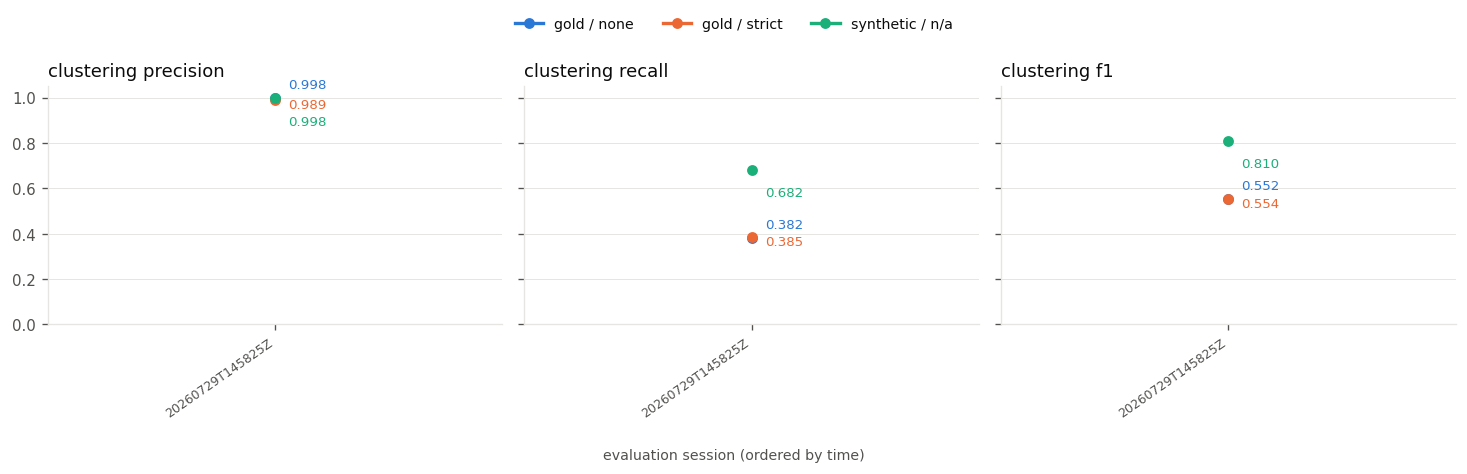

In [24]:
def plot_metric_history(reports, metrics=("precision", "recall", "f1"),
                        stage="clustering"):
    """Small multiples — one panel per metric, one shared y-axis scale.

    Small multiples rather than one panel with a second y-axis: precision,
    recall and F1 share a 0-1 scale, and a dual-axis chart would invite
    comparing quantities that are not comparable.
    """
    frames = {m: metric_history(reports, m, stage) for m in metrics}
    frames = {m: f for m, f in frames.items() if not f.empty}
    if not frames:
        print(f"No stored reports carry a '{stage}' {'/'.join(metrics)} value yet.")
        return

    order = (pd.concat(frames.values())
             .drop_duplicates("session_id")
             .sort_values("evaluated_utc")["session_id"].tolist())
    all_series = sorted({s for f in frames.values() for s in f["series"].unique()})
    colors = color_map(all_series)

    fig, axes = plt.subplots(1, len(frames), figsize=(4.1 * len(frames), 3.5),
                             sharey=True)
    axes = [axes] if len(frames) == 1 else list(axes)

    for ax, (metric, frame) in zip(axes, frames.items()):
        for name, grp in frame.groupby("series"):
            grp = grp.set_index("session_id").reindex(order).dropna(subset=["value"])
            xs = [order.index(r) for r in grp.index]
            ax.plot(xs, grp["value"], marker="o", markersize=5.5, linewidth=2,
                    color=colors[name], label=name, zorder=3)
            if len(all_series) <= 4 and len(xs):
                # Direct-label the last point, staggered by series index —
                # with a single run on the x-axis every series lands on the
                # same tick and un-staggered labels overprint each other.
                dy = 6 - 11 * all_series.index(name)
                ax.annotate(f"{grp['value'].iloc[-1]:.3f}",
                            (xs[-1], grp["value"].iloc[-1]),
                            textcoords="offset points", xytext=(8, dy),
                            fontsize=8, color=colors[name])
        ax.set_title(f"{stage} {metric}", color=INK, loc="left")
        ax.set_ylim(0, 1.05)
        ax.set_xticks(range(len(order)), order, rotation=35, ha="right", fontsize=7.5)
        ax.grid(axis="x", visible=False)

    handles, labels = axes[0].get_legend_handles_labels()
    if len(labels) >= 2:  # a single series is named by the title instead
        fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 3),
                   bbox_to_anchor=(0.5, 1.10), fontsize=8.5)
    fig.supxlabel("evaluation session (ordered by time)", color=MUTED, fontsize=8.5)
    plt.tight_layout()
    plt.show()


plot_metric_history(reports)

### 4.1 Table view of the same data

In [25]:
history = pd.concat([metric_history(reports, m) for m in ("precision", "recall", "f1")],
                    ignore_index=True)
if history.empty:
    print("Nothing to compare yet — evaluate at least one run.")
else:
    display(history.pivot_table(index=["evaluated_utc", "session_id", "series"],
                                columns="metric", values="value").round(4))

,,metric,f1,precision,recall
evaluated_utc,session_id,series,,,
2026-07-29T15:02:04+00:00,20260729T145825Z,gold / none,0.5521,0.9977,0.3817
2026-07-29T15:02:08+00:00,20260729T145825Z,gold / strict,0.5540,0.9887,0.3848
2026-07-29T15:02:20+00:00,20260729T145825Z,synthetic / n/a,0.8102,0.9978,0.6820


### 4.2 Any stage, not just clustering

Swap `stage` for any row of the per-stage table — `rules_auto_merge`,
`gate_pass`, `ml_auto_merge`, `blocking`. Remember the leakage rule: only read
`gate_pass` / `ml_auto_merge` from `strict` reports.

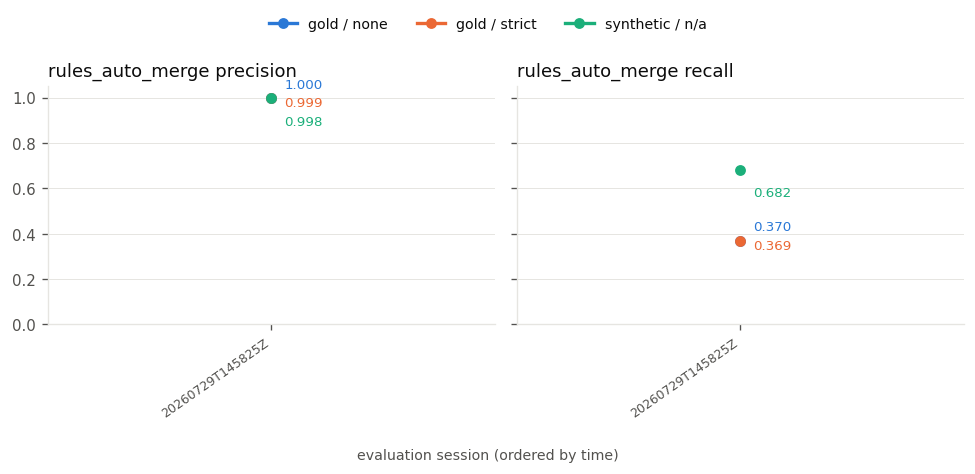

In [26]:
plot_metric_history(reports, metrics=("precision", "recall"), stage="rules_auto_merge")

## 5. Cluster-level metrics side by side

`truth_source` tells you how far to trust each row. Synthetic carries declared
entity ids, so its numbers are exact; gold's truth partition is inferred by
transitive closure of the positive pairs.

`nonsingleton_exact_rate` is the honest cluster number — the overall
`exact_rate` is dominated by the singletons the pipeline correctly leaves alone.

In [27]:
cluster_frame(reports)

,session_id,run_id,source,holdout,bcubed_precision,bcubed_recall,bcubed_f1,exact_rate,nonsingleton_exact_rate,nonsingleton_split,nonsingleton_merged,truth_source,closure_contradictions
0,20260729T145825Z,20260729T145825Z_synthetic,synthetic,n/a,0.9999,0.9682,0.9838,0.9643,0.6820,636,0,declared ground truth — no transitive closure ...,0
1,20260729T145825Z,20260729T145825Z_real,gold,strict,0.9369,0.9010,0.9186,0.7514,0.3571,1414,52,transitive closure of labels,2
2,20260729T145825Z,20260729T145825Z_real,gold,none,0.9999,0.6904,0.8168,0.5118,0.3473,23395,2,transitive closure of labels,802
